In [1]:
# Import Required Libraries
# Student Academic Performance Prediction Using Machine Learning

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Data Preprocessing
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

# Machine Learning Models
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import joblib

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Required Libraries Imported Successfully")

Required Libraries Imported Successfully


In [2]:
# Load Dataset

print("Loading Student Academic Performance Dataset")

# Import pandas 
import pandas as pd

# Load the dataset
df = pd.read_csv("golden data.csv")

# Display the first 10 rows
print("\nFirst 10 Records:")
print(df.head(10))

# Display the last 10 rows
print("\nLast 10 Records:")
print(df.tail(10))

# Display the shape of the dataset
print("\nDataset Shape:")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Loaded Successfully.")

Loading Student Academic Performance Dataset

First 10 Records:
   student_id  is_male age_group  study_hours_per_day  sleep_hours  gaming_hours  social_media_hours  attendance_percentage  stress_level  focus_score  Previous_Grades  is_passing final_grade
0           1        0     21-23                 4.35         3.63          5.26                2.73              57.209999            10           57         0.000000           1           B
1           2        1     18-20                 6.14         6.58          1.73                1.51              91.269997            10           49        60.599998           1           D
2           3        0     27-29                 4.98         3.26          4.71                3.63              63.139999             2           38         0.000000           1           B
3           4        0     27-29                 3.19         4.58          2.52                3.95              40.509998             6           50         0.000000 

In [3]:
# Explore Dataset

print("Exploring the Student Academic Performance Dataset")

# Dataset Information
print("\n1. Dataset Information")
df.info()

# Data Types
print("\n2. Data Types")
print(df.dtypes)

# Statistical Summary of Numerical Columns
print("\n3. Statistical Summary")
print(df.describe())

# Statistical Summary Including Categorical Columns
print("\n4. Summary Including Categorical Variables")
print(df.describe(include='all'))

# Check Missing Values
print("\n5. Missing Values")
print(df.isnull().sum())

# Total Missing Values
print("\nTotal Missing Values :", df.isnull().sum().sum())

# Check Duplicate Records
print("\n6. Duplicate Records")
print("Number of Duplicate Rows :", df.duplicated().sum())

# Unique Values in Each Column
print("\n7. Unique Values in Each Column")
print(df.nunique())

# Unique Values for Categorical Columns
print("\n8. Unique Categories")

categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())

# Dataset Memory Usage
print("\n9. Dataset Memory Usage")
memory = df.memory_usage(deep=True).sum() / (1024**2)
print(f"Memory Usage : {memory:.2f} MB")

print("Dataset Exploration Completed Successfully")

Exploring the Student Academic Performance Dataset

1. Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19222 entries, 0 to 19221
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             19222 non-null  int64  
 1   is_male                19222 non-null  int64  
 2   age_group              19222 non-null  object 
 3   study_hours_per_day    19222 non-null  float64
 4   sleep_hours            19222 non-null  float64
 5   gaming_hours           19222 non-null  float64
 6   social_media_hours     19222 non-null  float64
 7   attendance_percentage  19222 non-null  float64
 8   stress_level           19222 non-null  int64  
 9   focus_score            19222 non-null  int64  
 10  Previous_Grades        19222 non-null  float64
 11  is_passing             19222 non-null  int64  
 12  final_grade            19222 non-null  object 
dtypes: float64(6), int64(5), object

In [4]:
# Data Preprocessing

print("Data Preprocessing")

# Create a copy of the original dataset
data = df.copy()

# Drop Unnecessary Columns
print("\n1. Dropping Unnecessary Columns")

# student_id is only an identifier
data.drop(columns=["student_id"], inplace=True)

# Remove target leakage feature
data.drop(columns=["is_passing"], inplace=True)

print("student_id and is_passing columns removed successfully.")

# Encode Categorical Variables
print("\n2. Encoding Categorical Variables")


# Encode age_group using its natural order
age_order = [["15-17", "18-20", "21-23", "24-26", "27-29"]]

age_encoder = OrdinalEncoder(categories=age_order)

data["age_group"] = age_encoder.fit_transform(
    data[["age_group"]]
).astype(int)

print("age_group encoded successfully.")

# Encode target variable
grade_encoder = LabelEncoder()

data["final_grade"] = grade_encoder.fit_transform(
    data["final_grade"]
)

print("final_grade encoded successfully.")

print("\nEncoded Final Grade Classes:")

for index, label in enumerate(grade_encoder.classes_):
    print(f"{label} --> {index}")

# Split Features and Target
print("\n3. Splitting Features and Target Variable")

X = data.drop(columns=["final_grade"])
y = data["final_grade"]

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

# Display Processed Dataset
print("\n4. Processed Dataset (First 10 Rows)")
display(data.head(10))

print("\nProcessed Dataset Information")
data.info()

print("\nData Preprocessing Completed Successfully.")

Data Preprocessing

1. Dropping Unnecessary Columns
student_id and is_passing columns removed successfully.

2. Encoding Categorical Variables
age_group encoded successfully.
final_grade encoded successfully.

Encoded Final Grade Classes:
A --> 0
B --> 1
C --> 2
D --> 3
F --> 4

3. Splitting Features and Target Variable
Features Shape : (19222, 10)
Target Shape   : (19222,)

4. Processed Dataset (First 10 Rows)


,is_male,age_group,study_hours_per_day,sleep_hours,gaming_hours,social_media_hours,attendance_percentage,stress_level,focus_score,Previous_Grades,final_grade
0,0,2,4.35,3.63,5.26,2.73,57.209999,10,57,0.000000,1
1,1,1,6.14,6.58,1.73,1.51,91.269997,10,49,60.599998,3
2,0,4,4.98,3.26,4.71,3.63,63.139999,2,38,0.000000,1
3,0,4,3.19,4.58,2.52,3.95,40.509998,6,50,0.000000,2
4,1,3,7.67,6.21,5.65,1.59,45.529999,6,41,72.699997,0
5,0,2,9.06,6.36,4.44,5.99,43.500000,8,35,93.599998,3
6,0,2,6.37,4.86,5.13,1.37,75.220001,6,59,0.000000,3
7,1,3,4.19,4.87,3.38,2.87,44.790001,3,39,0.000000,2
8,0,1,7.28,9.56,2.55,0.81,79.150002,10,73,0.000000,1
9,1,2,6.38,7.83,1.36,1.72,54.990002,10,82,72.300003,2



Processed Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19222 entries, 0 to 19221
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   is_male                19222 non-null  int64  
 1   age_group              19222 non-null  int64  
 2   study_hours_per_day    19222 non-null  float64
 3   sleep_hours            19222 non-null  float64
 4   gaming_hours           19222 non-null  float64
 5   social_media_hours     19222 non-null  float64
 6   attendance_percentage  19222 non-null  float64
 7   stress_level           19222 non-null  int64  
 8   focus_score            19222 non-null  int64  
 9   Previous_Grades        19222 non-null  float64
 10  final_grade            19222 non-null  int64  
dtypes: float64(6), int64(5)
memory usage: 1.6 MB

Data Preprocessing Completed Successfully.


In [5]:
# Exploratory Data Analysis (EDA)

print("Exploratory Data Analysis (EDA)")

Exploratory Data Analysis (EDA)



Final Grade Distribution
final_grade
D    6421
A    3278
C    3233
B    3213
F    3077
Name: count, dtype: int64


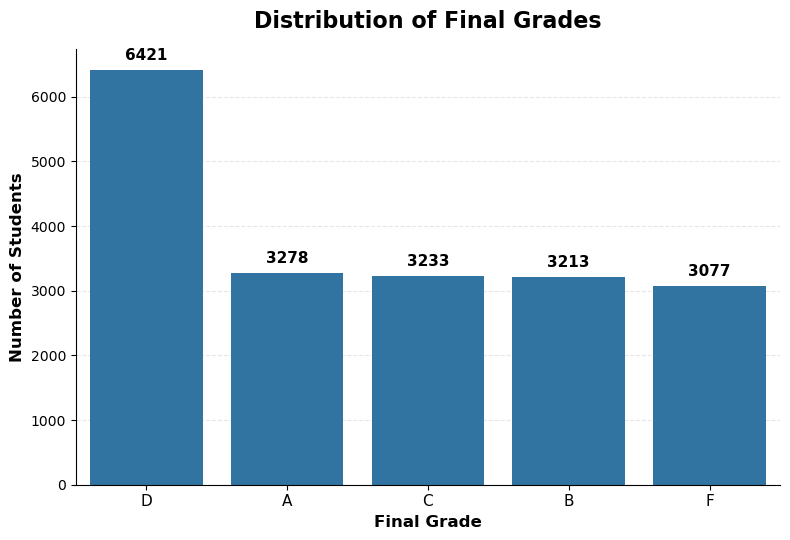

In [6]:
print("\nFinal Grade Distribution")
print(df["final_grade"].value_counts())

plt.figure(figsize=(8, 5.5))

ax = sns.countplot(
    x="final_grade",
    data=df,
    order=df["final_grade"].value_counts().index
)

# Title and axis labels
plt.title(
    "Distribution of Final Grades",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Final Grade",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Students",
    fontsize=12,
    fontweight="bold"
)

# Add light horizontal grid
ax.yaxis.grid(True, linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Remove unnecessary top and right borders
sns.despine()

# Display values on bars
for p in ax.patches:
    height = p.get_height()

    ax.annotate(
        f"{int(height)}",
        (
            p.get_x() + p.get_width() / 2,
            height
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points"
    )

# Improve spacing
plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()


Age Group Distribution
age_group
21-23    4463
24-26    4432
18-20    4399
27-29    4395
15-17    1533
Name: count, dtype: int64


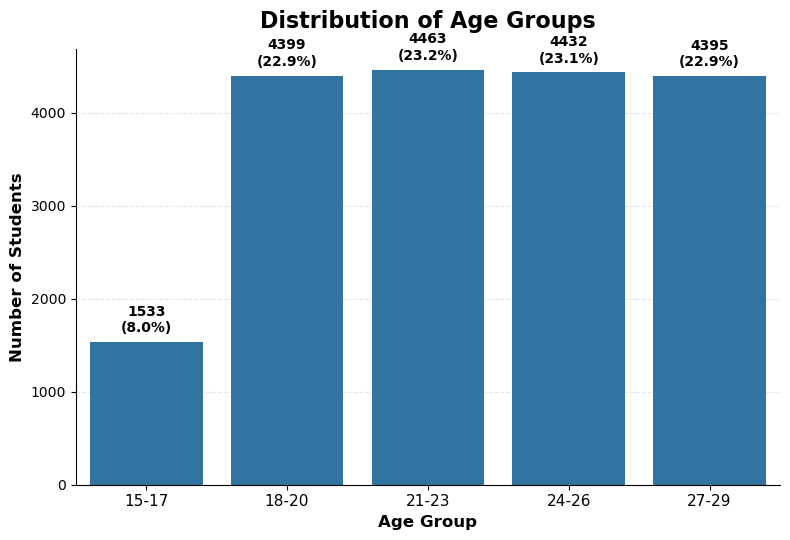

In [7]:
print("\nAge Group Distribution")
print(df["age_group"].value_counts())

plt.figure(figsize=(8, 5.5))

age_counts = df["age_group"].value_counts()

ax = sns.countplot(
    x="age_group",
    data=df,
    order=sorted(df["age_group"].unique())
)

plt.title(
    "Distribution of Age Groups",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Age Group",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Students",
    fontsize=12,
    fontweight="bold"
)

# Add light horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
sns.despine()

# Display number and percentage on each bar
total_students = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_students) * 100

    ax.annotate(
        f"{int(height)}\n({percentage:.1f}%)",
        (
            p.get_x() + p.get_width() / 2,
            height
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.xticks(
    fontsize=11
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

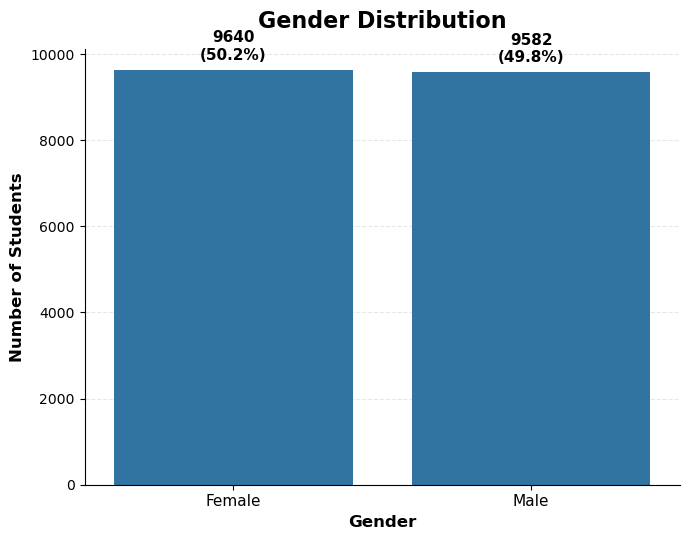

In [8]:
gender = df["is_male"].replace({
    0: "Female",
    1: "Male"
})

plt.figure(figsize=(7, 5.5))

gender_counts = gender.value_counts()
total_students = len(gender)

ax = sns.countplot(
    x=gender,
    order=gender_counts.index
)

plt.title(
    "Gender Distribution",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Gender",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Students",
    fontsize=12,
    fontweight="bold"
)

# Add light horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
sns.despine()

# Display count and percentage
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total_students) * 100

    ax.annotate(
        f"{int(height)}\n({percentage:.1f}%)",
        (
            p.get_x() + p.get_width() / 2,
            height
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.xticks(
    fontsize=11
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

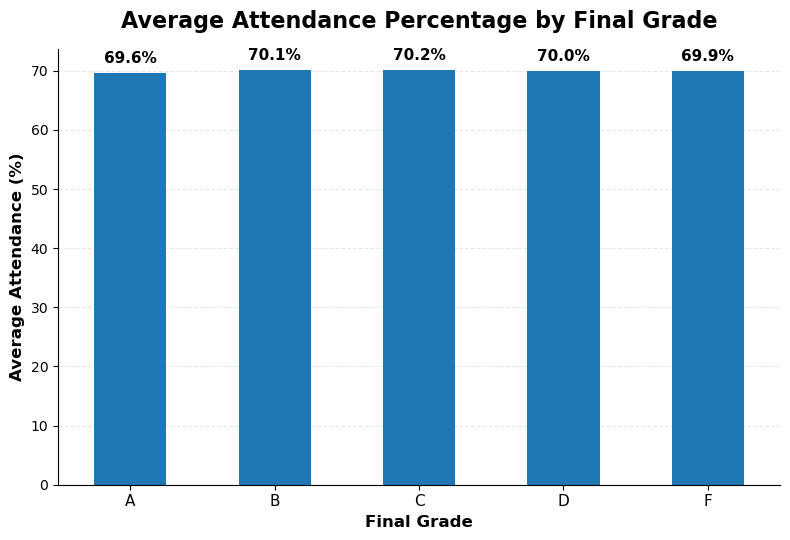

In [9]:
attendance = df.groupby("final_grade")["attendance_percentage"].mean()

plt.figure(figsize=(8, 5.5))

ax = attendance.plot(
    kind="bar",
    figsize=(8, 5.5)
)

plt.title(
    "Average Attendance Percentage by Final Grade",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Final Grade",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Attendance (%)",
    fontsize=12,
    fontweight="bold"
)

# Add light horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
sns.despine()

# Display values on bars
for p in ax.patches:
    height = p.get_height()

    ax.annotate(
        f"{height:.1f}%",
        (
            p.get_x() + p.get_width() / 2,
            height
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.xticks(
    rotation=0,
    fontsize=11
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

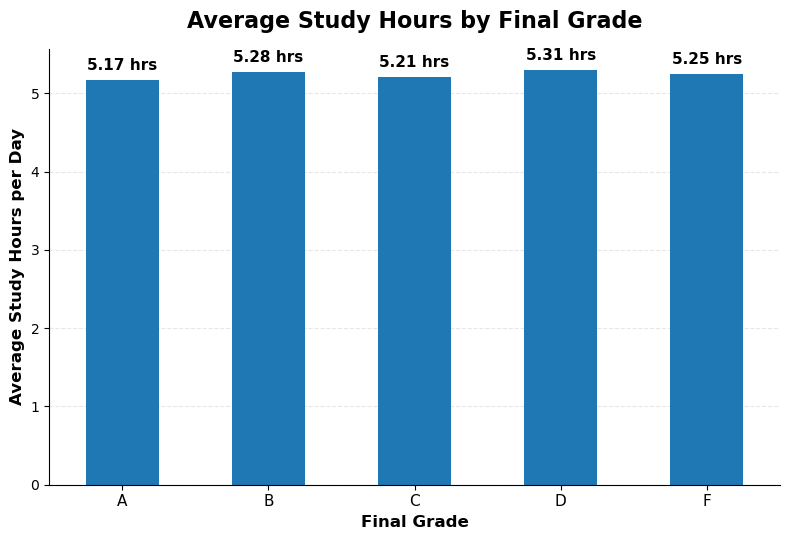

In [10]:
study = df.groupby("final_grade")["study_hours_per_day"].mean()

plt.figure(figsize=(8, 5.5))

ax = study.plot(
    kind="bar",
    figsize=(8, 5.5)
)

plt.title(
    "Average Study Hours by Final Grade",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Final Grade",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Average Study Hours per Day",
    fontsize=12,
    fontweight="bold"
)

# Add light horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
sns.despine()

# Display values on bars
for p in ax.patches:
    height = p.get_height()

    ax.annotate(
        f"{height:.2f} hrs",
        (
            p.get_x() + p.get_width() / 2,
            height
        ),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        xytext=(0, 5),
        textcoords="offset points"
    )

plt.xticks(
    rotation=0,
    fontsize=11
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

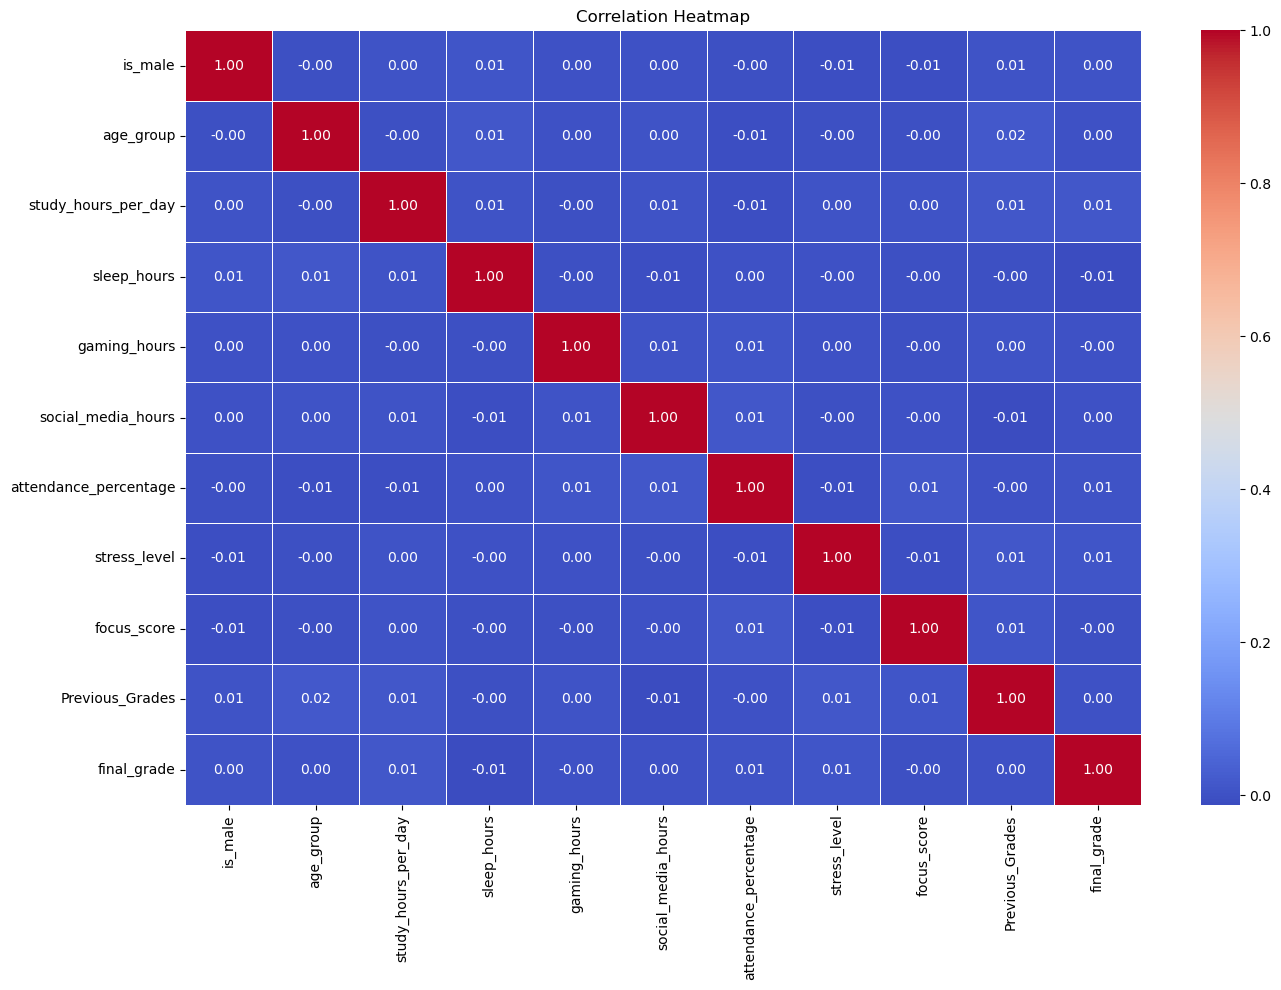

In [11]:
plt.figure(figsize=(14,10))

corr = data.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

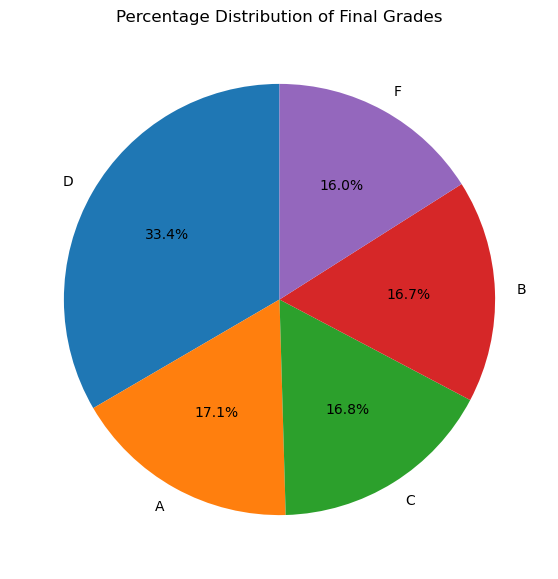

In [12]:
grade = df["final_grade"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    grade,
    labels=grade.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage Distribution of Final Grades")

plt.show()

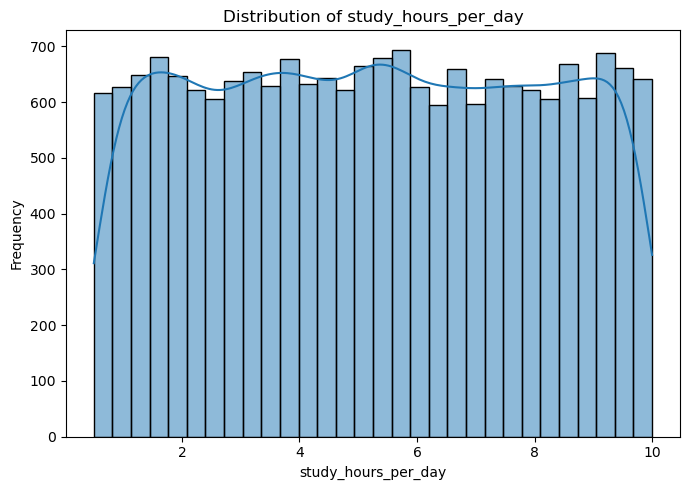

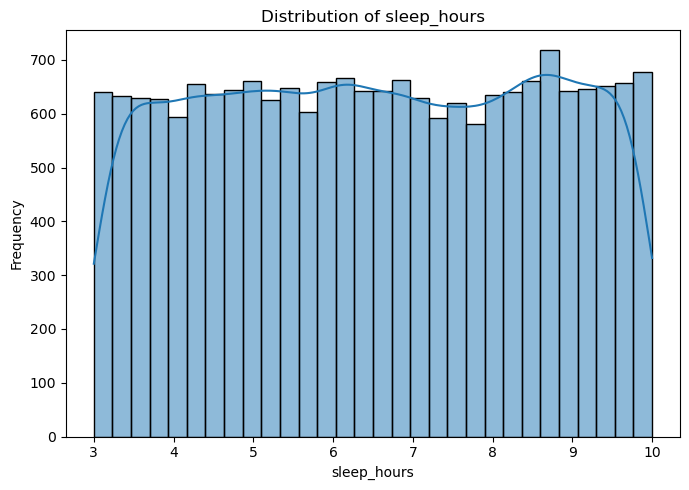

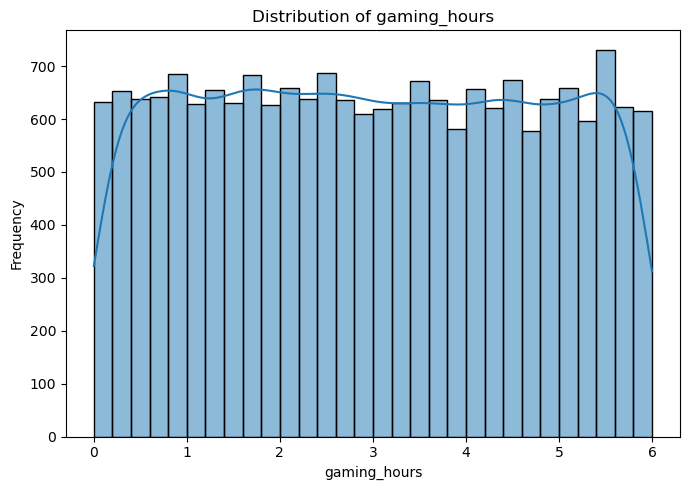

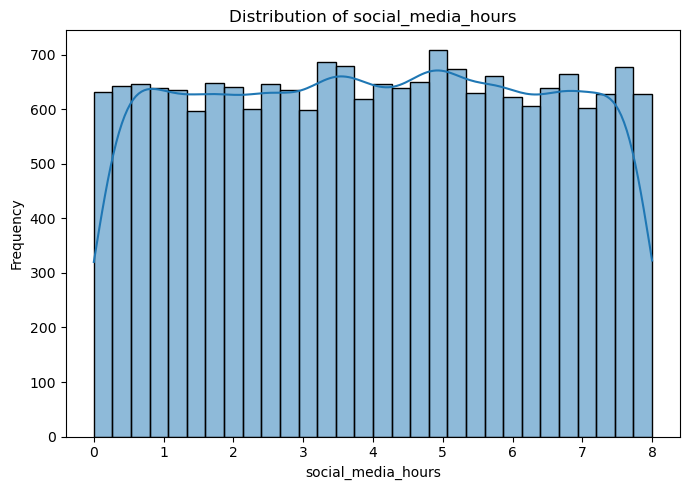

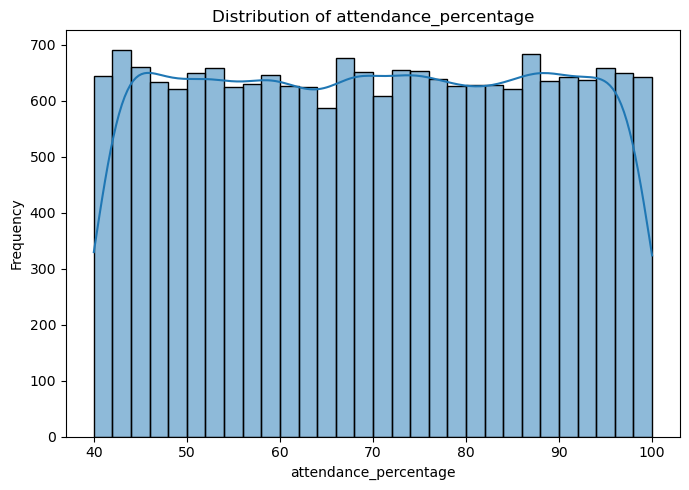

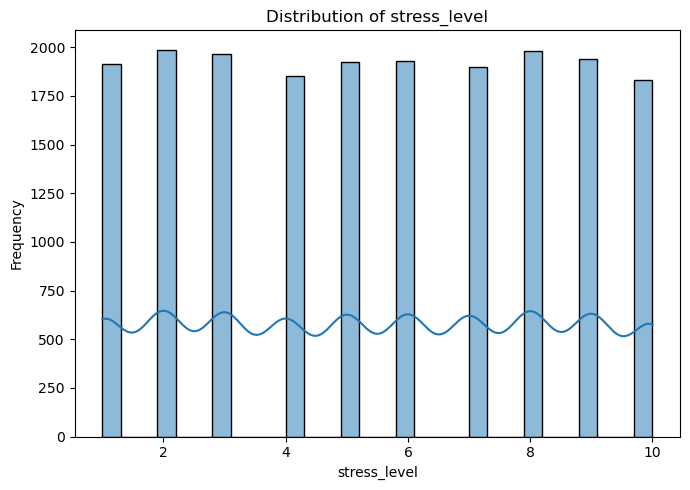

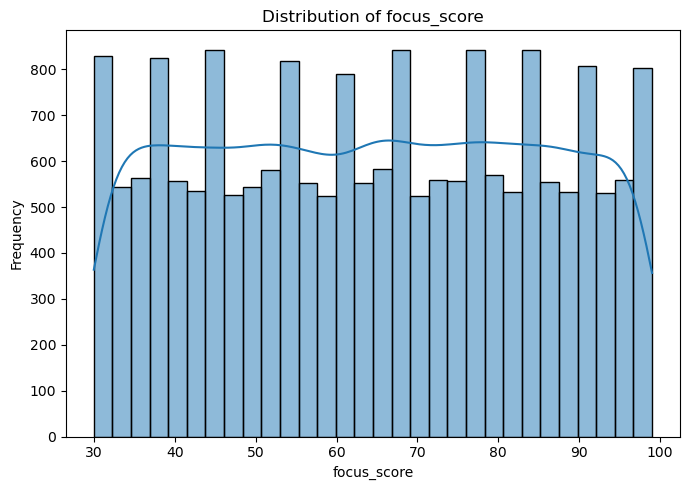

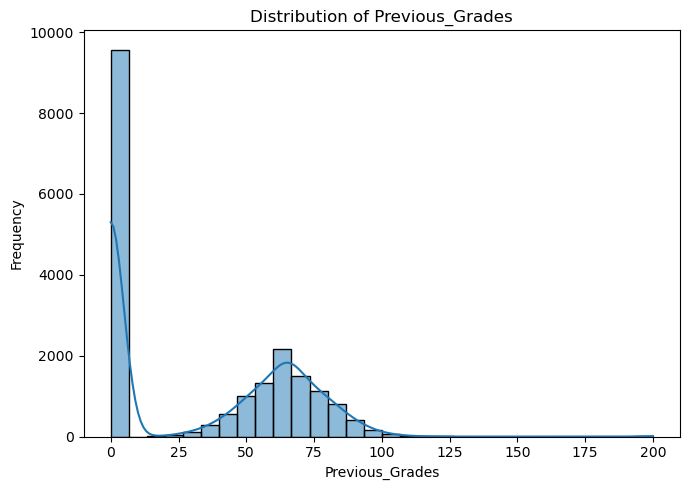

In [13]:
numerical_columns = [

    "study_hours_per_day",

    "sleep_hours",

    "gaming_hours",

    "social_media_hours",

    "attendance_percentage",

    "stress_level",

    "focus_score",

    "Previous_Grades"

]

for column in numerical_columns:

    plt.figure(figsize=(7,5))

    ax = sns.histplot(
        df[column],
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.show()

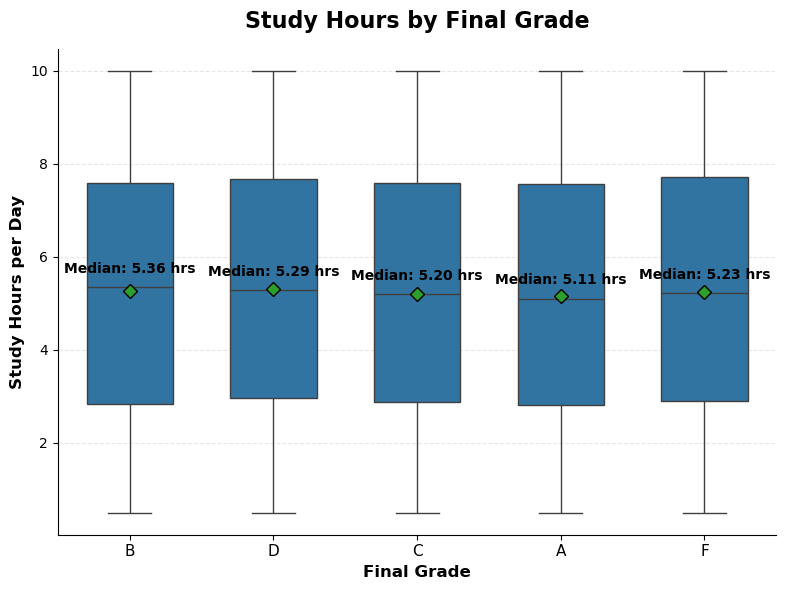

In [14]:
plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    x="final_grade",
    y="study_hours_per_day",
    data=df,
    width=0.6,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.title(
    "Study Hours by Final Grade",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Final Grade",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Study Hours per Day",
    fontsize=12,
    fontweight="bold"
)

# Add light horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
sns.despine()

# Add median values above each box
median_values = df.groupby(
    "final_grade"
)["study_hours_per_day"].median()

grade_order = df["final_grade"].unique()

for i, grade in enumerate(ax.get_xticklabels()):
    grade_name = grade.get_text()
    median_value = median_values[grade_name]

    ax.annotate(
        f"Median: {median_value:.2f} hrs",
        (
            i,
            median_value
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 8),
        textcoords="offset points"
    )

plt.xticks(
    fontsize=11,
    rotation=0
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

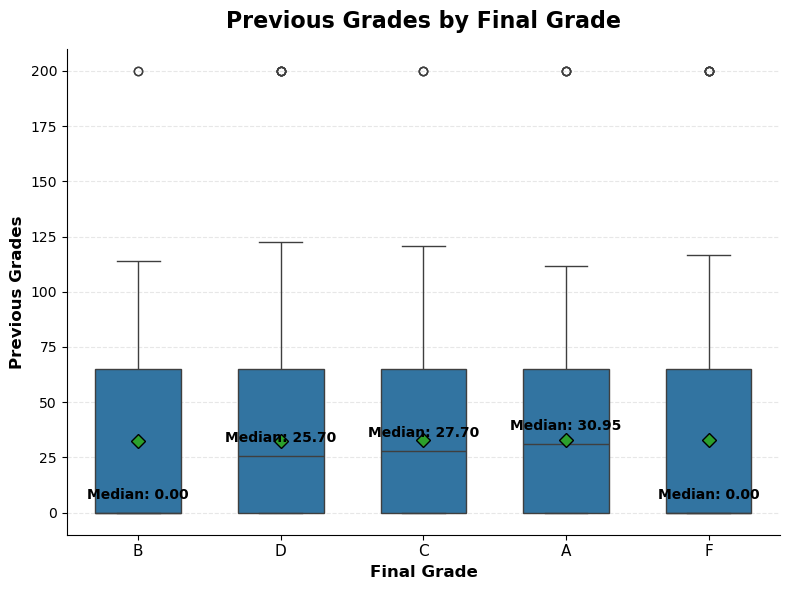

In [15]:
# Previous Grades by Final Grade

plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    x="final_grade",
    y="Previous_Grades",
    data=df,
    width=0.6,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.title(
    "Previous Grades by Final Grade",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Final Grade",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Previous Grades",
    fontsize=12,
    fontweight="bold"
)

# Add horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
sns.despine()

# Calculate median values
median_values = df.groupby(
    "final_grade"
)["Previous_Grades"].median()

# Display median values
for i, grade in enumerate(ax.get_xticklabels()):

    grade_name = grade.get_text()
    median_value = median_values[grade_name]

    ax.annotate(
        f"Median: {median_value:.2f}",
        (
            i,
            median_value
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 8),
        textcoords="offset points"
    )

plt.xticks(
    fontsize=11,
    rotation=0
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

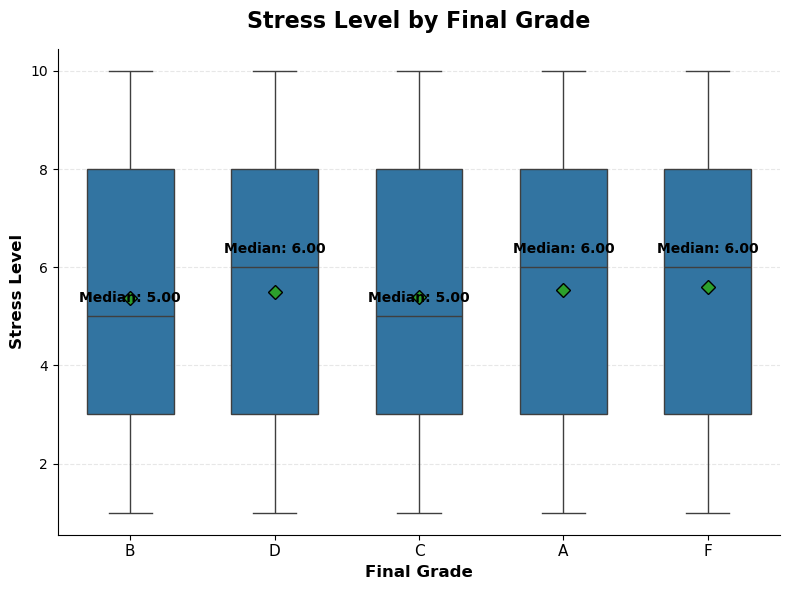

In [16]:
# 11. Stress Level by Final Grade

plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    x="final_grade",
    y="stress_level",
    data=df,
    width=0.6,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.title(
    "Stress Level by Final Grade",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Final Grade",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Stress Level",
    fontsize=12,
    fontweight="bold"
)

# Add horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
sns.despine()

# Calculate median stress level for each grade
median_values = df.groupby(
    "final_grade"
)["stress_level"].median()

# Display median values
for i, grade in enumerate(ax.get_xticklabels()):

    grade_name = grade.get_text()
    median_value = median_values[grade_name]

    ax.annotate(
        f"Median: {median_value:.2f}",
        (
            i,
            median_value
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 8),
        textcoords="offset points"
    )

plt.xticks(
    fontsize=11,
    rotation=0
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

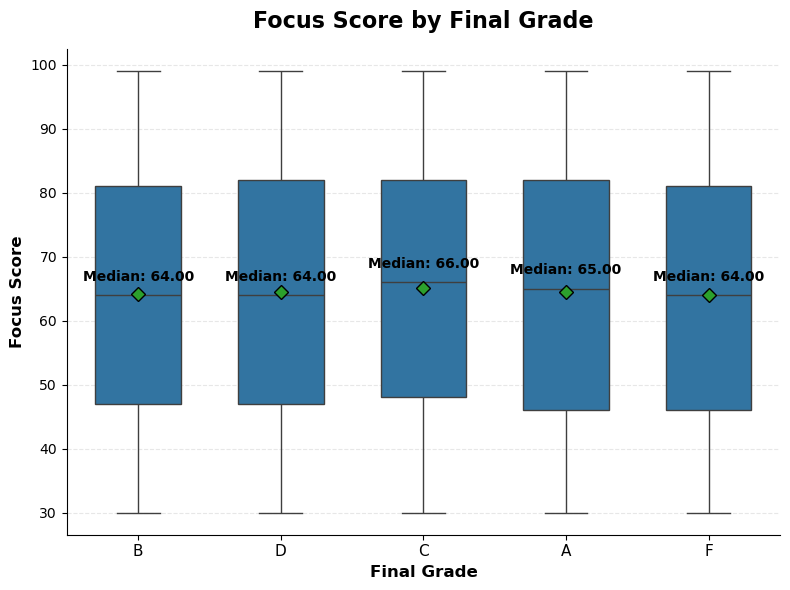

Exploratory Data Analysis Completed Successfully


In [17]:
# Focus Score by Final Grade

plt.figure(figsize=(8, 6))

ax = sns.boxplot(
    x="final_grade",
    y="focus_score",
    data=df,
    width=0.6,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.title(
    "Focus Score by Final Grade",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Final Grade",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Focus Score",
    fontsize=12,
    fontweight="bold"
)

# Add horizontal grid
ax.yaxis.grid(
    True,
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

# Remove unnecessary borders
sns.despine()

# Calculate median focus score for each grade
median_values = df.groupby(
    "final_grade"
)["focus_score"].median()

# Display median values
for i, grade in enumerate(ax.get_xticklabels()):

    grade_name = grade.get_text()
    median_value = median_values[grade_name]

    ax.annotate(
        f"Median: {median_value:.2f}",
        (
            i,
            median_value
        ),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        xytext=(0, 8),
        textcoords="offset points"
    )

plt.xticks(
    fontsize=11,
    rotation=0
)

plt.yticks(
    fontsize=10
)

plt.tight_layout()
plt.show()

print("Exploratory Data Analysis Completed Successfully")

In [18]:
print("Feature Engineering")

feature_data = data.copy()

# Study Efficiency
feature_data["study_efficiency"] = (
    feature_data["study_hours_per_day"] *
    feature_data["focus_score"] / 100
)

print("Study Efficiency created.")

# Academic Engagement
feature_data["academic_engagement"] = (
    feature_data["study_hours_per_day"] *
    feature_data["attendance_percentage"] / 100
)

print("Academic Engagement created.")

# Lifestyle Balance
feature_data["lifestyle_balance"] = (
    feature_data["sleep_hours"]
    - feature_data["gaming_hours"]
    - feature_data["social_media_hours"]
)

print("Lifestyle Balance created.")

# Entertainment Hours
feature_data["entertainment_hours"] = (
    feature_data["gaming_hours"]
    + feature_data["social_media_hours"]
)

print("Entertainment Hours created.")

# Focus-Stress Ratio
feature_data["focus_stress_ratio"] = (
    feature_data["focus_score"] /
    (feature_data["stress_level"] + 1)
)

print("Focus-Stress Ratio created.")

# Study-Entertainment Ratio
feature_data["study_entertainment_ratio"] = (
    feature_data["study_hours_per_day"] /
    (feature_data["entertainment_hours"] + 1)
)

print("Study-Entertainment Ratio created.")

# Sleep Quality
feature_data["sleep_quality"] = (
    feature_data["sleep_hours"] /
    (feature_data["stress_level"] + 1)
)

print("Sleep Quality created.")

# Attendance Focus
feature_data["attendance_focus"] = (
    feature_data["attendance_percentage"] *
    feature_data["focus_score"] / 100
)

print("Attendance Focus created.")

# Prepare Features and Target
X = feature_data.drop("final_grade", axis=1)
y = feature_data["final_grade"]

print("\nDataset Shape :", feature_data.shape)

print("\nFeature Columns")
print(X.columns.tolist())

print("\nFeatures Shape :", X.shape)
print("Target Shape   :", y.shape)

print("\nFirst 5 Rows")
print(feature_data.head())

print("\nFeature Engineering Completed Successfully.")

Feature Engineering
Study Efficiency created.
Academic Engagement created.
Lifestyle Balance created.
Entertainment Hours created.
Focus-Stress Ratio created.
Study-Entertainment Ratio created.
Sleep Quality created.
Attendance Focus created.

Dataset Shape : (19222, 19)

Feature Columns
['is_male', 'age_group', 'study_hours_per_day', 'sleep_hours', 'gaming_hours', 'social_media_hours', 'attendance_percentage', 'stress_level', 'focus_score', 'Previous_Grades', 'study_efficiency', 'academic_engagement', 'lifestyle_balance', 'entertainment_hours', 'focus_stress_ratio', 'study_entertainment_ratio', 'sleep_quality', 'attendance_focus']

Features Shape : (19222, 18)
Target Shape   : (19222,)

First 5 Rows
   is_male  age_group  study_hours_per_day  sleep_hours  gaming_hours  social_media_hours  attendance_percentage  stress_level  focus_score  Previous_Grades  final_grade  study_efficiency  academic_engagement  lifestyle_balance  entertainment_hours  focus_stress_ratio  study_entertainment_

In [19]:
from sklearn.model_selection import train_test_split

print("Train-Test Split")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

print("\nTrain-Test Split Completed Successfully.")

Train-Test Split

Training Features : (15377, 18)
Testing Features  : (3845, 18)
Training Target   : (15377,)
Testing Target    : (3845,)

Train-Test Split Completed Successfully.


In [20]:
# Feature Selection using Mutual Information

from sklearn.feature_selection import SelectKBest, mutual_info_classif

print("Feature Selection using Mutual Information")

# Select the 10 most informative features
k_features = min(10, X_train.shape[1])

selector = SelectKBest(
    score_func=mutual_info_classif,
    k=k_features
)

# Fit feature selection ONLY on training data
X_train_selected_array = selector.fit_transform(X_train, y_train)

# Apply the same feature selection to test data
X_test_selected_array = selector.transform(X_test)

# Get selected feature names
selected_features = X_train.columns[
    selector.get_support()
]

# Convert selected arrays back to DataFrames
X_train_selected = pd.DataFrame(
    X_train_selected_array,
    columns=selected_features,
    index=X_train.index
)

X_test_selected = pd.DataFrame(
    X_test_selected_array,
    columns=selected_features,
    index=X_test.index
)

# Feature scores
feature_scores = pd.DataFrame({
    "Feature": X_train.columns,
    "Mutual Information Score": selector.scores_
}).sort_values(
    by="Mutual Information Score",
    ascending=False
)

print("\nSelected Features:")
print(selected_features.tolist())

print("\nFeature Scores:")
display(feature_scores)

Feature Selection using Mutual Information

Selected Features:
['gaming_hours', 'social_media_hours', 'stress_level', 'academic_engagement', 'lifestyle_balance', 'entertainment_hours', 'focus_stress_ratio', 'study_entertainment_ratio', 'sleep_quality', 'attendance_focus']

Feature Scores:


,Feature,Mutual Information Score
7,stress_level,0.009242
17,attendance_focus,0.007888
14,focus_stress_ratio,0.007684
12,lifestyle_balance,0.006837
11,academic_engagement,0.006150
5,social_media_hours,0.004863
13,entertainment_hours,0.004758
15,study_entertainment_ratio,0.003059
4,gaming_hours,0.000758
16,sleep_quality,0.000580


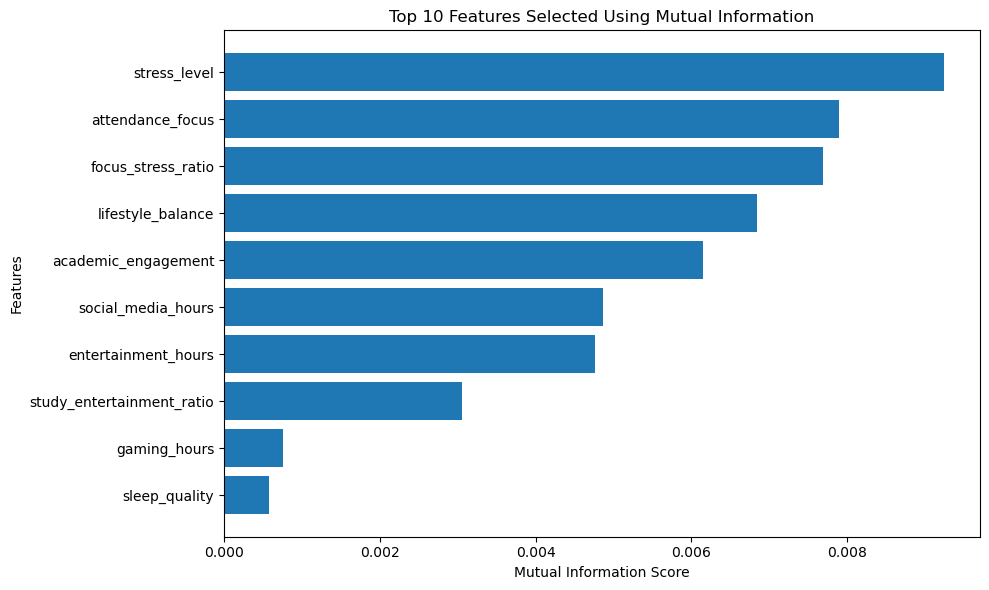

In [21]:
# Mutual Information Feature Ranking

top_features = feature_scores.head(10).sort_values(
    by="Mutual Information Score",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Mutual Information Score"]
)

plt.title(
    "Top 10 Features Selected Using Mutual Information"
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [22]:
# Scaling Selected Features

from sklearn.preprocessing import StandardScaler

scaler_selected = StandardScaler()

X_train_selected_scaled = scaler_selected.fit_transform(
    X_train_selected
)

X_test_selected_scaled = scaler_selected.transform(
    X_test_selected
)

print("Selected features scaled successfully.")

print("Training shape:", X_train_selected_scaled.shape)
print("Testing shape:", X_test_selected_scaled.shape)

Selected features scaled successfully.
Training shape: (15377, 10)
Testing shape: (3845, 10)


In [23]:
# Hyperparameter Tuning

print("Hyperparameter Tuning")

# ------------------------------------------------------------
# Logistic Regression Parameters
# ------------------------------------------------------------

lr_params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "solver": ["lbfgs", "liblinear", "saga"],
    "penalty": ["l2"],
    "max_iter": [500, 1000, 2000]
}


# ------------------------------------------------------------
# Decision Tree Parameters
# ------------------------------------------------------------

dt_params = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [5, 10, 15, 20, 25, 30, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": [None, "sqrt", "log2"]
}


# ------------------------------------------------------------
# Random Forest Parameters
# ------------------------------------------------------------

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [10, 20, 30, 40, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True, False]
}


# ------------------------------------------------------------
# Support Vector Machine Parameters
# ------------------------------------------------------------

svm_params = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale"]
}


# ------------------------------------------------------------
# K-Nearest Neighbors Parameters
# ------------------------------------------------------------

knn_params = {
    "n_neighbors": [3, 5, 7, 9, 11, 13],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2]
}


print("Hyperparameter grids created successfully.")

Hyperparameter Tuning
Hyperparameter grids created successfully.


In [24]:
# Logistic Regression

print("Training Logistic Regression...")

lr_grid = GridSearchCV(
    estimator=LogisticRegression(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=lr_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Logistic Regression uses scaled selected features
lr_grid.fit(
    X_train_selected_scaled,
    y_train
)

best_lr = lr_grid.best_estimator_

print("\nBest Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(lr_grid.best_score_, 4))

Training Logistic Regression...

Best Parameters:
{'C': 0.001, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}

Best Cross Validation Accuracy:
0.33


In [25]:
# Decision Tree

print("Training Decision Tree...")

dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# Decision Tree uses selected features without scaling
dt_grid.fit(
    X_train_selected,
    y_train
)

best_dt = dt_grid.best_estimator_

print("\nBest Parameters:")
print(dt_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(dt_grid.best_score_, 4))

Training Decision Tree...

Best Parameters:
{'criterion': 'gini', 'max_depth': 25, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Cross Validation Accuracy:
0.2278


In [26]:
# Random Forest

print("Training Random Forest...")

rf_grid = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_distributions=rf_params,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

# Random Forest uses selected features without scaling
rf_grid.fit(
    X_train_selected,
    y_train
)

best_rf = rf_grid.best_estimator_

print("\nBest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(rf_grid.best_score_, 4))

Training Random Forest...

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'criterion': 'gini', 'bootstrap': True}

Best Cross Validation Accuracy:
0.2804


In [27]:
# Support Vector Machine

print("Training Support Vector Machine...")

svm_grid = RandomizedSearchCV(
    estimator=SVC(
        random_state=42
    ),
    param_distributions=svm_params,
    n_iter=4,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

# SVM uses scaled selected features
svm_grid.fit(
    X_train_selected_scaled,
    y_train
)

best_svm = svm_grid.best_estimator_

print("\nBest Parameters:")
print(svm_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(svm_grid.best_score_, 4))

Training Support Vector Machine...

Best Parameters:
{'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}

Best Cross Validation Accuracy:
0.3341


In [28]:
# K-Nearest Neighbors

print("Training K-Nearest Neighbors...")

knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# KNN uses scaled selected features
knn_grid.fit(
    X_train_selected_scaled,
    y_train
)

best_knn = knn_grid.best_estimator_

print("\nBest Parameters:")
print(knn_grid.best_params_)

print("\nBest Cross Validation Accuracy:")
print(round(knn_grid.best_score_, 4))

Training K-Nearest Neighbors...

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 13, 'p': 1, 'weights': 'distance'}

Best Cross Validation Accuracy:
0.2661


In [29]:
# Model Comparison

print("Model Comparison")

# Predictions using selected features
lr_pred = best_lr.predict(
    X_test_selected_scaled
)

dt_pred = best_dt.predict(
    X_test_selected
)

rf_pred = best_rf.predict(
    X_test_selected
)

svm_pred = best_svm.predict(
    X_test_selected_scaled
)

knn_pred = best_knn.predict(
    X_test_selected_scaled
)

# ------------------------------------------------------------
# Performance Metrics
# ------------------------------------------------------------

models_predictions = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Support Vector Machine": svm_pred,
    "K-Nearest Neighbors": knn_pred
}

results_list = []

for model_name, predictions in models_predictions.items():

    results_list.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ) * 100,

        "Precision": precision_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ) * 100,

        "Recall": recall_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ) * 100,

        "F1-Score": f1_score(
            y_test,
            predictions,
            average="weighted",
            zero_division=0
        ) * 100,

        "Macro F1": f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        ) * 100
    })

results = pd.DataFrame(results_list)

results = results.round(2)

print("\nModel Performance Comparison:")
display(results)

Model Comparison

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,Macro F1
0,Logistic Regression,32.95,13.95,32.95,17.51,11.01
1,Decision Tree,19.53,20.94,19.53,19.76,18.31
2,Random Forest,28.63,22.65,28.63,22.45,17.78
3,Support Vector Machine,33.39,11.15,33.39,16.72,10.01
4,K-Nearest Neighbors,26.94,22.72,26.94,23.23,19.18


In [31]:
# ============================================================
# Classification Report for Best Model
# ============================================================

# Class labels for the five final-grade categories
class_labels = ["A", "B", "C", "D", "F"]

# Store predictions from all models
best_prediction_map = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Support Vector Machine": svm_pred,
    "K-Nearest Neighbors": knn_pred
}

# Select the best model based on Accuracy
best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_predictions = best_prediction_map[
    best_model_name
]

print(
    f"Classification Report - {best_model_name}"
)

print(
    classification_report(
        y_test,
        best_predictions,
        labels=[0, 1, 2, 3, 4],
        target_names=class_labels,
        digits=4,
        zero_division=0
    )
)

Classification Report - Support Vector Machine
              precision    recall  f1-score   support

           A     0.0000    0.0000    0.0000       656
           B     0.0000    0.0000    0.0000       643
           C     0.0000    0.0000    0.0000       647
           D     0.3339    1.0000    0.5007      1284
           F     0.0000    0.0000    0.0000       615

    accuracy                         0.3339      3845
   macro avg     0.0668    0.2000    0.1001      3845
weighted avg     0.1115    0.3339    0.1672      3845



In [32]:
# Best Model
best_model = results.loc[results["Accuracy"].idxmax()]

print("Best Performing Model")
print("Model :", best_model["Model"])
print("Accuracy :", best_model["Accuracy"], "%")

Best Performing Model
Model : Support Vector Machine
Accuracy : 33.39 %


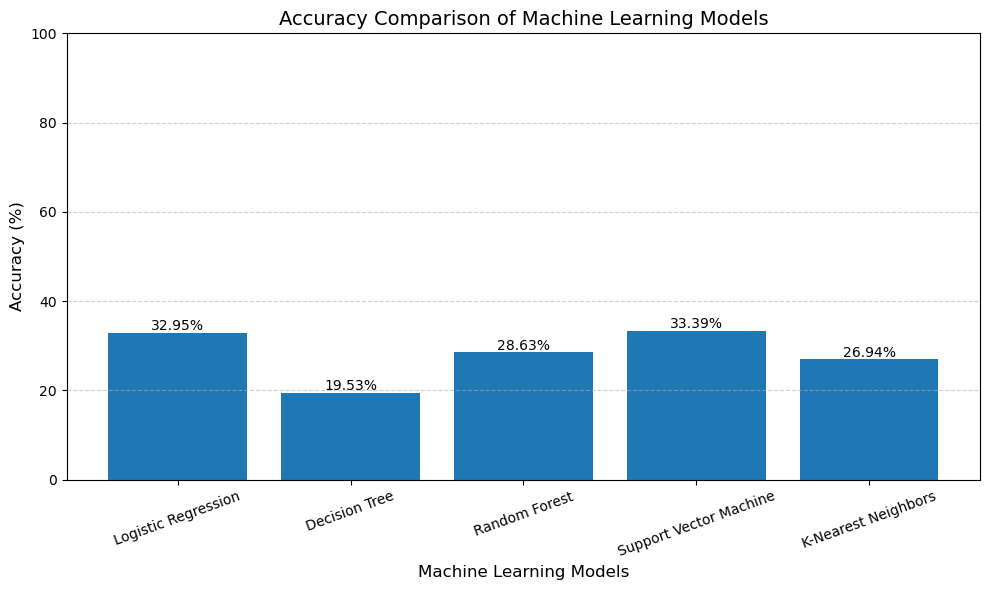

In [33]:
# Accuracy Comparison Chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Accuracy Comparison of Machine Learning Models", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=20)

# Display accuracy values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

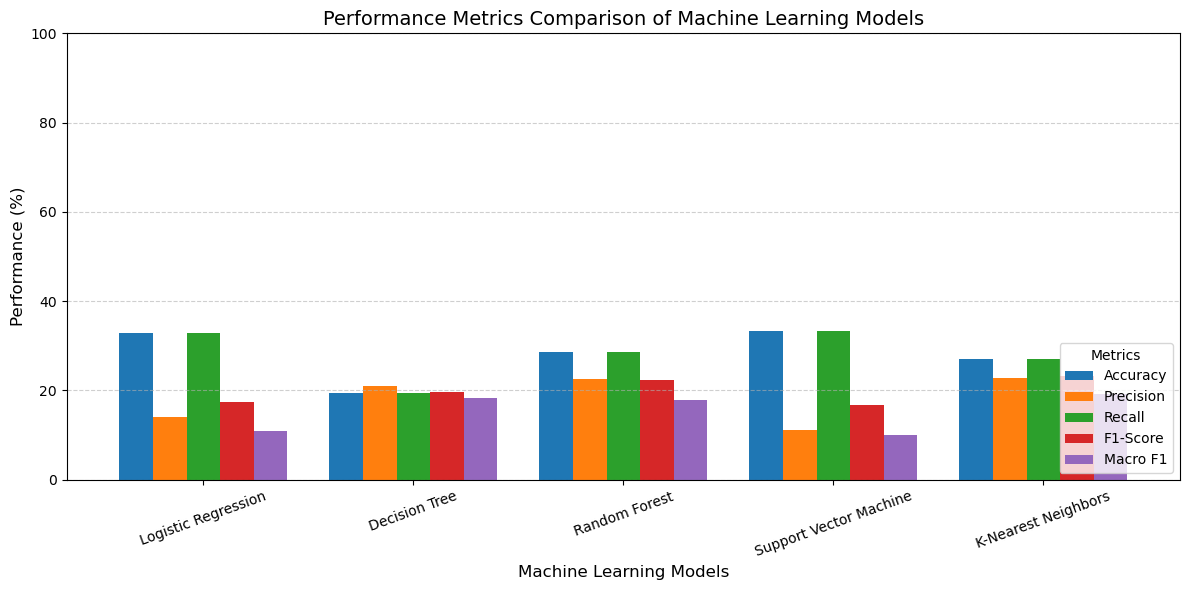

In [34]:
# Performance Metrics Comparison Chart
metrics = results.set_index("Model")

ax = metrics.plot(
    kind="bar",
    figsize=(12, 6),
    width=0.8
)

plt.title("Performance Metrics Comparison of Machine Learning Models", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Performance (%)", fontsize=12)
plt.xticks(rotation=20)
plt.ylim(0, 100)

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.legend(
    title="Metrics",
    loc="lower right"
)

plt.tight_layout()
plt.show()

Confusion Matrices


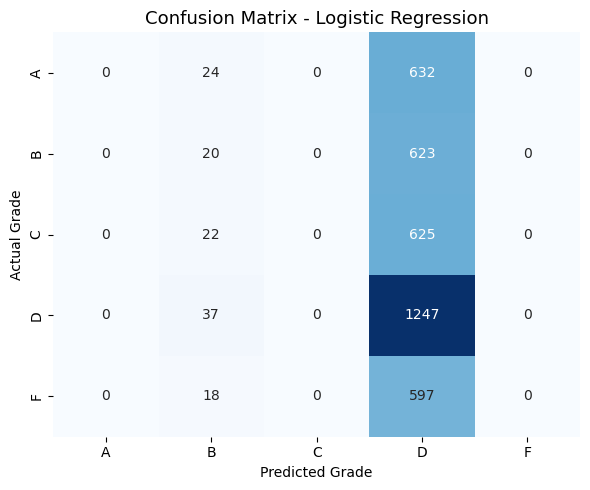

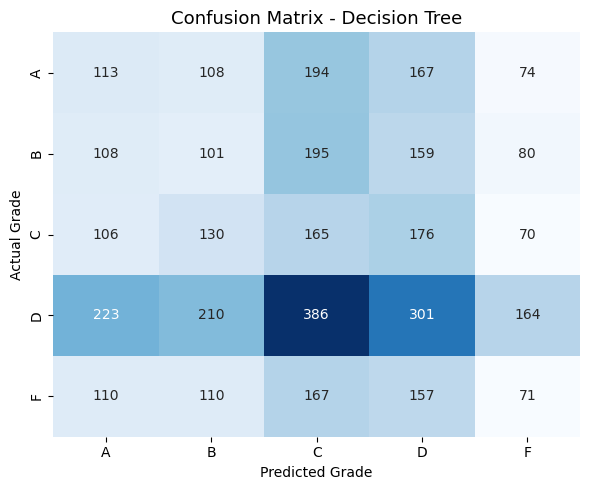

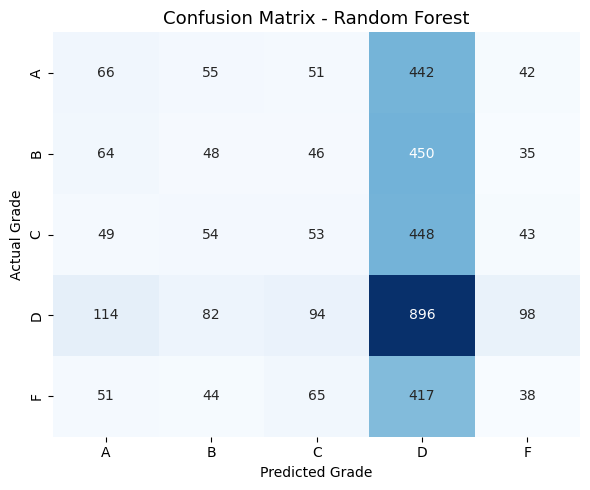

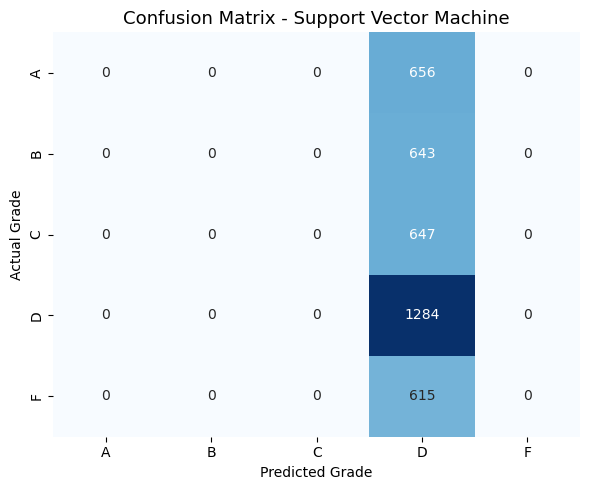

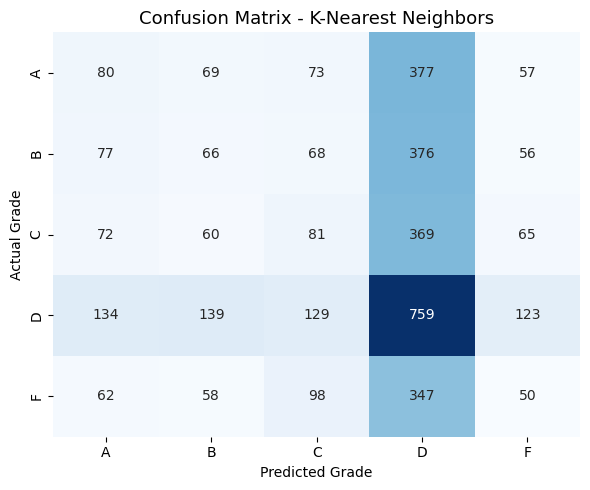

In [35]:
# Confusion Matrices

print("Confusion Matrices")

models = {
    "Logistic Regression": (
        best_lr,
        X_test_selected_scaled
    ),

    "Decision Tree": (
        best_dt,
        X_test_selected
    ),

    "Random Forest": (
        best_rf,
        X_test_selected
    ),

    "Support Vector Machine": (
        best_svm,
        X_test_selected_scaled
    ),

    "K-Nearest Neighbors": (
        best_knn,
        X_test_selected_scaled
    )
}

class_labels = ["A", "B", "C", "D", "F"]

for model_name, (model, X_data) in models.items():

    predictions = model.predict(X_data)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=13
    )

    plt.xlabel("Predicted Grade")
    plt.ylabel("Actual Grade")

    plt.tight_layout()
    plt.show()

Feature Importance

Decision Tree Feature Importance:


,Feature,Importance
3,academic_engagement,0.124242
8,sleep_quality,0.118682
9,attendance_focus,0.115554
7,study_entertainment_ratio,0.108395
4,lifestyle_balance,0.104501
5,entertainment_hours,0.104473
1,social_media_hours,0.102969
0,gaming_hours,0.097384
6,focus_stress_ratio,0.091809
2,stress_level,0.031991


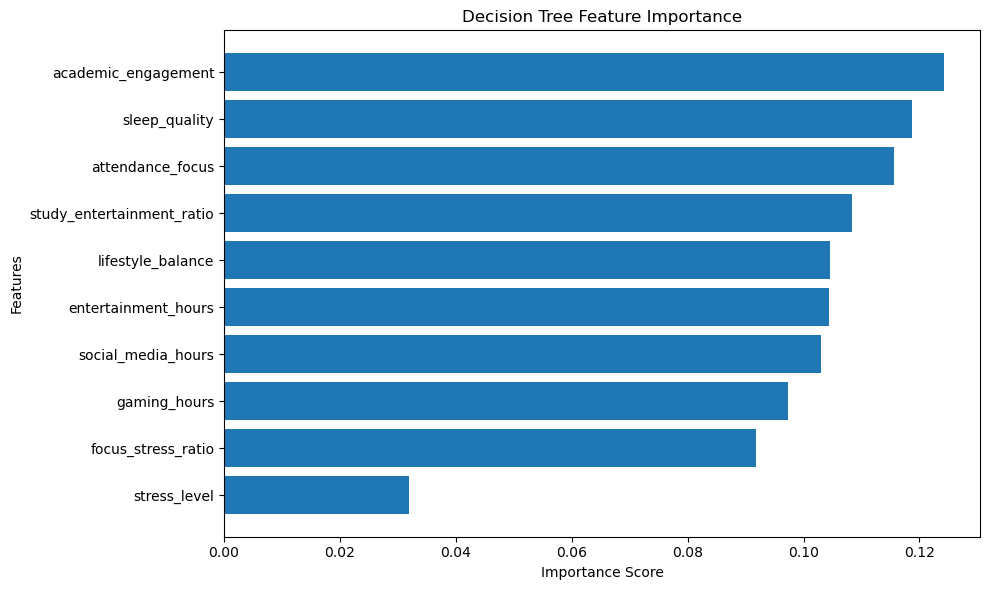


Random Forest Feature Importance:


,Feature,Importance
9,attendance_focus,0.112663
3,academic_engagement,0.111255
7,study_entertainment_ratio,0.108887
4,lifestyle_balance,0.108072
8,sleep_quality,0.107447
0,gaming_hours,0.105420
1,social_media_hours,0.103467
6,focus_stress_ratio,0.102123
5,entertainment_hours,0.101591
2,stress_level,0.039076


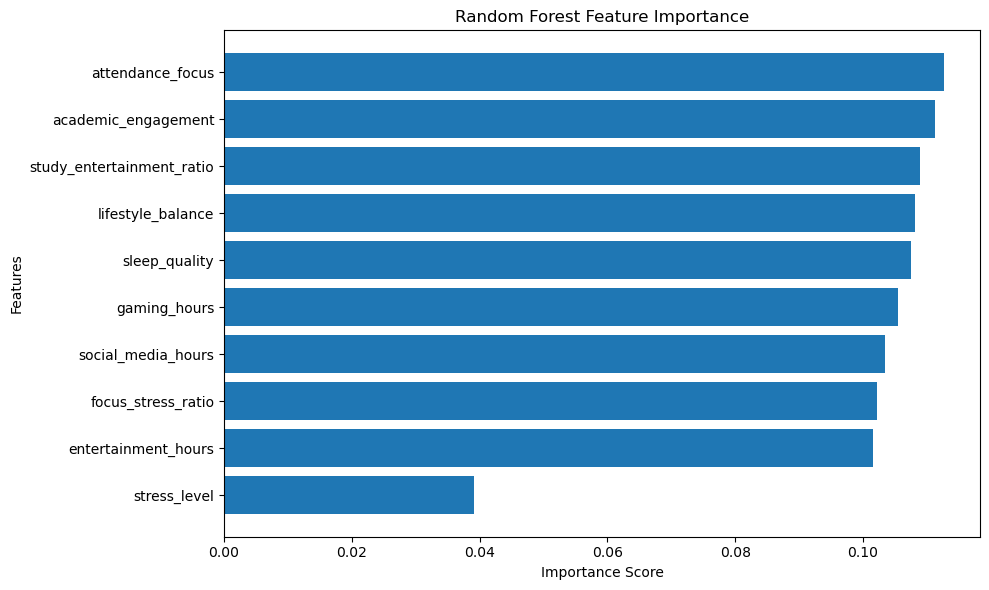

In [36]:
# Feature Importance

print("Feature Importance")

# ------------------------------------------------------------
# Decision Tree Feature Importance
# ------------------------------------------------------------

dt_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": best_dt.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nDecision Tree Feature Importance:")
display(dt_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    dt_importance["Feature"],
    dt_importance["Importance"]
)

plt.title(
    "Decision Tree Feature Importance"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Random Forest Feature Importance
# ------------------------------------------------------------

rf_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": best_rf.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("\nRandom Forest Feature Importance:")
display(rf_importance)

plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [37]:
# Cross Validation Results

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

print("Cross Validation Results")

# Logistic Regression
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_lr)
])

lr_cv = cross_val_score(
    lr_pipeline,
    X_train_selected,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
).mean()


# Decision Tree
dt_cv = cross_val_score(
    best_dt,
    X_train_selected,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
).mean()


# Random Forest
rf_cv = cross_val_score(
    best_rf,
    X_train_selected,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
).mean()


# Support Vector Machine
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_svm)
])

svm_cv = cross_val_score(
    svm_pipeline,
    X_train_selected,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
).mean()


# K-Nearest Neighbors
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", best_knn)
])

knn_cv = cross_val_score(
    knn_pipeline,
    X_train_selected,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
).mean()


# Create results table
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "K-Nearest Neighbors"
    ],

    "Cross Validation Accuracy": [
        lr_cv,
        dt_cv,
        rf_cv,
        svm_cv,
        knn_cv
    ]
})

cv_results["Cross Validation Accuracy"] = (
    cv_results["Cross Validation Accuracy"] * 100
).round(2)

print("\nCross Validation Results:")
display(cv_results)

Cross Validation Results

Cross Validation Results:


,Model,Cross Validation Accuracy
0,Logistic Regression,33.00
1,Decision Tree,22.78
2,Random Forest,28.04
3,Support Vector Machine,33.41
4,K-Nearest Neighbors,26.62


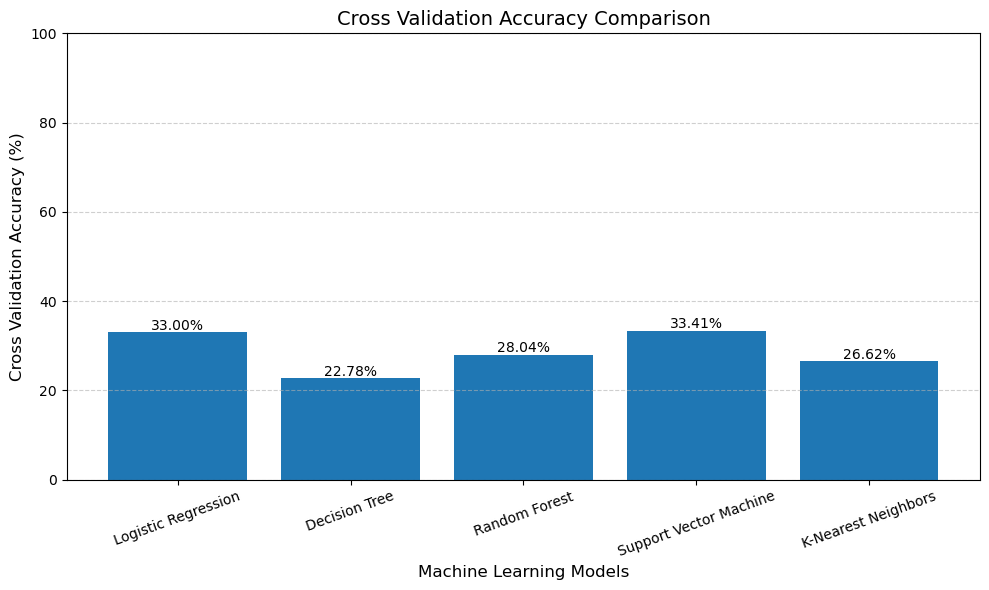

In [38]:
# Cross Validation Accuracy Chart
plt.figure(figsize=(10, 6))

bars = plt.bar(
    cv_results["Model"],
    cv_results["Cross Validation Accuracy"]
)

plt.title("Cross Validation Accuracy Comparison", fontsize=14)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.ylabel("Cross Validation Accuracy (%)", fontsize=12)
plt.ylim(0, 100)
plt.xticks(rotation=20)

plt.grid(axis="y", linestyle="--", alpha=0.6)

# Display accuracy values above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [39]:
# Save Best Model and Preprocessing Objects

import joblib

print("Saving Best Model")

model_objects = {
    "Logistic Regression": best_lr,
    "Decision Tree": best_dt,
    "Random Forest": best_rf,
    "Support Vector Machine": best_svm,
    "K-Nearest Neighbors": best_knn
}

# Select best model based on test accuracy
best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]

best_model = model_objects[
    best_model_name
]

# Store everything required for future prediction
model_package = {
    "model": best_model,
    "feature_selector": selector,
    "selected_features": selected_features.tolist(),
    "scaler": scaler_selected,
    "grade_encoder": grade_encoder
}

filename = (
    best_model_name
    .lower()
    .replace(" ", "_")
    + "_with_feature_selection.pkl"
)

joblib.dump(
    model_package,
    filename
)

print(
    f"Best model ({best_model_name}) "
    "saved successfully."
)

print(
    f"Filename: {filename}"
)

print(
    "\nSelected features used by final model:"
)

print(
    selected_features.tolist()
)

Saving Best Model
Best model (Support Vector Machine) saved successfully.
Filename: support_vector_machine_with_feature_selection.pkl

Selected features used by final model:
['gaming_hours', 'social_media_hours', 'stress_level', 'academic_engagement', 'lifestyle_balance', 'entertainment_hours', 'focus_stress_ratio', 'study_entertainment_ratio', 'sleep_quality', 'attendance_focus']
